<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_2_Question_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


In [2]:
img = cv2.imread('/content/dog.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

In [3]:
def dft_filter(image, padding=False):
    if padding:
        rows, cols = image.shape
        nrows = cv2.getOptimalDFTSize(rows * 2)
        ncols = cv2.getOptimalDFTSize(cols * 2)
        padded = np.zeros((nrows, ncols), dtype=np.float32)
        padded[:rows, :cols] = image.astype(np.float32)
    else:
        padded = image.astype(np.float32)

    dft = cv2.dft(padded, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    crow, ccol = dft_shift.shape[0]//2, dft_shift.shape[1]//2
    mask = np.zeros(dft_shift.shape, np.float32)
    r = 30
    mask[crow - r:crow + r, ccol - r:ccol + r] = 1

    fshift = dft_shift * mask

    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    if padding:
        img_back = img_back[:image.shape[0], :image.shape[1]]

    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return img_back

In [4]:
result_no_padding = dft_filter(img, padding=False)

result_with_padding = dft_filter(img, padding=True)

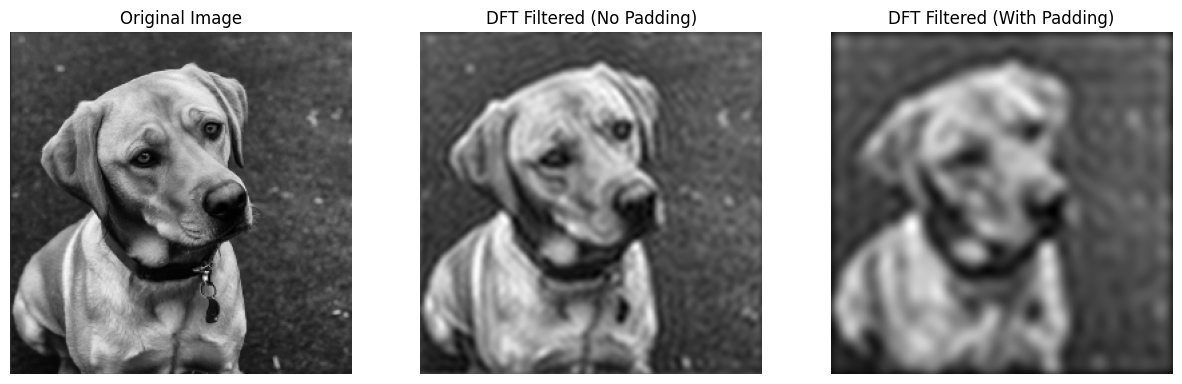

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(result_no_padding, cmap='gray')
plt.title('DFT Filtered (No Padding)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_with_padding, cmap='gray')
plt.title('DFT Filtered (With Padding)')
plt.axis('off')

plt.show()